# Phase drift × low-bit quantization: impact on Rsum

Validates the joint effect of **RF-chain phase drift** (independent per-antenna phase error, applied *after* the DAC — the same mechanism as the G-BF controlled phase-error injection in the Techtile WPT paper) and **low-bit DAC quantization** on communication performance, measured as sum rate (`Rsum`, via the Bussgang decomposition already used throughout this repo).

Pipeline per channel realization (perfect CSI is used to design the precoder — the phase error models RF hardware/synchronization drift, not CSI staleness):

```
x = W @ s                              # ideal ZF/MRT precoding
y = Q(x)                               # per-antenna non-uniform DAC (AGC-scaled)
y_drift = diag(exp(j*dtheta)) @ y      # dtheta_m ~ N(0, sigma_theta^2), i.i.d. per antenna, fixed within the channel realization
r = H^T @ y_drift                      # true channel, ideal receiver sync
Rsum = bussgang_at_receiver(S, r, noise_vars)
```

Three cases compared, as agreed:
- **(A)** no quantization, no phase drift — reference upper bound
- **(B)** low-bit quantization only, no phase drift
- **(C)** low-bit quantization **and** phase drift, swept over `sigma_theta`

A diagnostic decomposition (coherent signal power vs. distortion spatial-correlation) is included at the end to separate the two competing effects: coherent combining loss vs. quantization-noise decorrelation.

In [27]:
import os, sys

# notebook lives in precoding_quantization/non_lin_precoding/Phase_impact/
# -> project root (importable package root, holding utils/ and MIMO_sims/) is two levels up
CURRENT_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print(f'{CURRENT_DIR=}')
print(f'{PROJECT_ROOT=}')

import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

from utils.utils import rayleigh_channel_MU, symbols_MU, cellfree_channel_MU
from utils.quantization import quantize_nonuniform
from utils.precoding import ZF_precoding, MRT_precoding
from MIMO_sims.Rsum_all import bussgang_at_receiver

CURRENT_DIR='d:\\Documents\\Pycharm_Files\\Quantization\\precoding_quantization\\non_lin_precoding\\Phase_impact'
PROJECT_ROOT='d:\\Documents\\Pycharm_Files\\Quantization\\precoding_quantization'


In [28]:
def simulate_rsum_phase_drift(H, snr_points, Pt, bits=None, sigma_theta=0.0,
                               quant_params_path=None, precoding='zf-mrt',
                               nrdata=5000, rng=None, return_diagnostics=False):
    """
    Rsum under DAC quantization + post-quantization per-antenna RF-chain phase drift.

    Pipeline per channel realization:
        x = W @ s                              (ideal precoding, perfect CSI)
        y = Q(x)                               (per-antenna non-uniform DAC, AGC-scaled)
        y_drift = diag(exp(1j*dtheta)) @ y      (dtheta ~ N(0, sigma_theta^2) per antenna,
                                                  fixed for this channel realization / coherence block)
        r = H^T @ y_drift
        Rsum = bussgang_at_receiver(S, r, noise_vars)   (reused from MIMO_sims/Rsum_all.py)

    bits=None        -> no quantization (y = x)
    sigma_theta=0.0  -> no phase drift (y_drift = y)

    If return_diagnostics, also returns a dict averaged over channel realizations:
        - coherent_pwr: mean |diag(H^T G)|^2 (useful signal power after coherent combining)
        - dist_offdiag_ratio: mean (sum|Cq off-diag|) / (sum|Cq diag|), TX-side distortion
          covariance Cq = cov(y_drift - G@S) -- higher means more spatially correlated distortion
    """
    if rng is None:
        rng = np.random.default_rng()

    K = H.shape[-1]
    M = H.shape[-2]
    noise_vars = Pt / (10 ** (snr_points / 10))

    if bits is not None:
        thresholds = np.load(os.path.join(quant_params_path, f'{bits}bits_thresholds.npy'))
        outputlevels = np.load(os.path.join(quant_params_path, f'{bits}bits_outputlevels.npy'))

    n_channels = H.shape[0]
    R_all = np.zeros((n_channels, len(noise_vars)))
    coherent_pwr = np.zeros(n_channels)
    dist_offdiag_ratio = np.zeros(n_channels)

    desc = f'bits={bits}, sigma_theta={np.rad2deg(sigma_theta):.0f}deg'
    for i in trange(n_channels, desc=desc):
        Hi = H[i, :, :]

        # precoding (perfect CSI, unaware of the downstream drift)
        if precoding == 'zf-mrt':
            W = MRT_precoding(Hi, Pt) if K == 1 else ZF_precoding(Hi, Pt)
        else:
            raise ValueError(f'unsupported precoding {precoding}')

        S = symbols_MU(K, nrdata=nrdata)
        x = W @ S

        # per-antenna DAC (AGC-scaled, mirrors Rsum_Bussgang_Rx in MIMO_sims/Rsum_all.py)
        if bits is not None:
            alpha_m = np.array([np.real(W[m, :] @ W[m, :].conj()) for m in range(M)])
            x_scaled = (1 / np.sqrt(alpha_m))[:, None] * x
            xq = quantize_nonuniform(x_scaled, thresholds, outputlevels)
            y = np.sqrt(alpha_m)[:, None] * xq
        else:
            y = x

        # RF-chain phase drift, applied after the DAC, fixed for this channel realization
        if sigma_theta > 0:
            dtheta = rng.normal(0, sigma_theta, size=M)
            y_drift = np.exp(1j * dtheta)[:, None] * y
        else:
            y_drift = y

        # send over the true channel (receiver assumed perfectly synchronized)
        r = Hi.T @ y_drift
        R_all[i, :] = bussgang_at_receiver(S, r, noise_vars)

        if return_diagnostics:
            # per-antenna Bussgang fit of y_drift wrt s: y_drift = G @ S + q
            cov_s = (S @ S.conj().T) / nrdata
            G = ((y_drift @ S.conj().T) / nrdata) @ np.linalg.inv(cov_s)   # M x K
            q = y_drift - G @ S

            HTG = Hi.T @ G
            coherent_pwr[i] = np.mean(np.abs(np.diag(HTG)) ** 2)

            Cq = (q @ q.conj().T) / nrdata
            diag_energy = np.sum(np.abs(np.diag(Cq)))
            offdiag_energy = np.sum(np.abs(Cq)) - diag_energy
            dist_offdiag_ratio[i] = offdiag_energy / (diag_energy + 1e-12)

    Rsum_avg = np.mean(R_all, axis=0)

    if return_diagnostics:
        diagnostics = {
            'coherent_pwr': np.mean(coherent_pwr),
            'dist_offdiag_ratio': np.mean(dist_offdiag_ratio),
        }
        return Rsum_avg, diagnostics
    return Rsum_avg

## Simulation parameters and the three cases (A/B/C)

In [29]:
# ---- simulation parameters ----
np.random.seed(42)

M, K = 16, 2                   # antennas, users (K>1 -> ZF precoding, exercises inter-user interference too)
Pt = M                          # avg transmit power constraint
varx = 0.5                      # Gaussian_var used for the pre-computed non-uniform quantizer params
bits = 1                         # bit depth used for cases B and C (1-bit: most extreme, most likely to show the tension)
n_channels = 300                  # Monte Carlo channel realizations
nrdata = 5000                      # symbols per channel realization (used to estimate the Bussgang gain)

snr_points = np.array([-30, -20, -10, 0, 10, 20, 30])

quant_params_path = os.path.join(PROJECT_ROOT, 'non-uniform-quant-params', f'Gaussian_var_{varx}', 'numerical')

# channel model: 'iid' (Rayleigh, collocated array) or 'cellfree' (distributed APs with large-scale fading)
# -> phase drift is specifically a distributed-MIMO/cell-free concern (each AP has its own free-running LO;
#    a collocated array normally shares one LO and stays phase-coherent), so 'cellfree' is the more realistic setting here
channel_model = 'cellfree'

# cell-free deployment parameters (same defaults as non_lin_precoding/data_handling.py)
cellfree_kwargs = dict(area_side_m=100.0, min_distance_m=10.0, pathloss_exponent=3.7,
                        shadowing_std_db=8.0, pathloss_at_1m_db=-30.0)

# fixed set of channel realizations, shared across all three cases for a fair comparison
H = np.zeros((n_channels, M, K), dtype=complex)
if channel_model == 'iid':
    for i in range(n_channels):
        H[i, :, :] = rayleigh_channel_MU(M, K)
elif channel_model == 'cellfree':
    ap_pos = None  # AP geometry drawn once, then kept fixed; only UE positions/small-scale fading vary per realization
    for i in range(n_channels):
        H[i, :, :], ap_pos = cellfree_channel_MU(M=M, K=K, ap_positions=ap_pos, **cellfree_kwargs)

    # Real path loss over a 100m area makes mean|H|^2 ~1e-8 (vs. 1 for iid Rayleigh): with pathloss_exponent=3.7
    # and pathloss_at_1m_db=-30dB, a 50m link already sees ~-100dB of large-scale attenuation. snr_points below is
    # a *transmit*-SNR (Pt / noise_var, channel-gain-independent), so without renormalizing, that ~1e-8 factor would
    # just sit entirely in the noise term and collapse every SNR point's Rsum to ~0 regardless of sigma_theta or bits.
    # Rescale by a single global scalar (computed once from this batch of channels) so that mean|H|^2 = 1, matching
    # the iid convention and keeping snr_points meaningful -- this preserves all relative AP/user gain differences
    # (near vs. far users, shadowing) intact, it only re-anchors the average operating point.
    H = H / np.sqrt(np.mean(np.abs(H) ** 2))
else:
    raise ValueError(f'unsupported channel_model: {channel_model}')

rng_A = np.random.default_rng(1)
rng_B = np.random.default_rng(2)
rng_C = np.random.default_rng(3)

# (A) no quantization, no phase drift -- reference upper bound
Rsum_A = simulate_rsum_phase_drift(H, snr_points, Pt, bits=None, sigma_theta=0.0,
                                    quant_params_path=quant_params_path, nrdata=nrdata, rng=rng_A)

# (B) quantization only, no phase drift
Rsum_B = simulate_rsum_phase_drift(H, snr_points, Pt, bits=bits, sigma_theta=0.0,
                                    quant_params_path=quant_params_path, nrdata=nrdata, rng=rng_B)

# (C) quantization + phase drift, at one representative sigma_theta (finer sweep done further below)
sigma_theta_repr = np.deg2rad(20)
Rsum_C = simulate_rsum_phase_drift(H, snr_points, Pt, bits=bits, sigma_theta=sigma_theta_repr,
                                    quant_params_path=quant_params_path, nrdata=nrdata, rng=rng_C)

bits=1, sigma_theta=20deg: 100%|██████████| 300/300 [00:01<00:00, 180.21it/s]


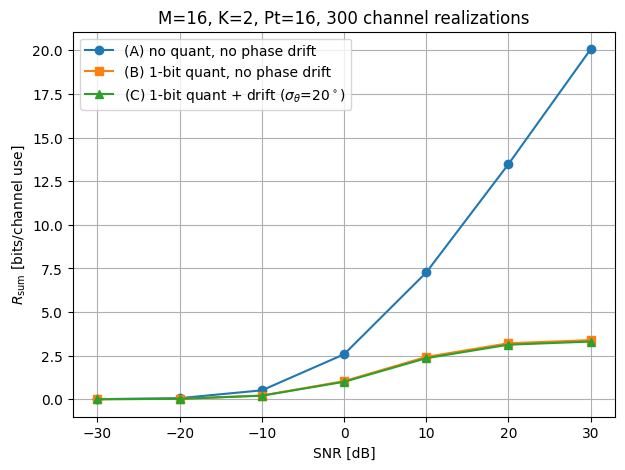

In [30]:
plt.figure(figsize=(7, 5))
plt.plot(snr_points, Rsum_A, marker='o', label='(A) no quant, no phase drift')
plt.plot(snr_points, Rsum_B, marker='s', label=f'(B) {bits}-bit quant, no phase drift')
plt.plot(snr_points, Rsum_C, marker='^',
         label=f'(C) {bits}-bit quant + drift ($\\sigma_\\theta$={np.rad2deg(sigma_theta_repr):.0f}$^\\circ$)')
plt.xlabel('SNR [dB]')
plt.ylabel(r'$R_{\mathrm{sum}}$ [bits/channel use]')
plt.title(f'M={M}, K={K}, Pt={Pt}, {n_channels} channel realizations')
plt.legend()
plt.grid(True)
plt.show()

## $\sigma_\theta$ sweep at a fixed SNR, across DAC resolutions: does lower bit depth make phase drift more or less costly?

Case (C) is now swept over `sigma_theta`, **repeated for `bits in [1, 2, 3]`**, at a fixed representative SNR, and compared against the (A) upper bound and each bit depth's own (B) reference level (quantization only, no drift) at that same SNR. Same color = same bit depth; dotted black = (A), dashed = (B) reference, solid+marker = (C) sweep.

Note: this repeats the simulation 3x (once per bit depth), so this cell takes roughly 3x longer than the single-bit version.

In [31]:
# sigma_theta sweep at a fixed, representative SNR (distortion-limited regime, where quantization matters most)
# repeated for bits in [1, 2, 3] to compare DAC resolutions
snr_fixed = 20.0  # dB
snr_idx = np.argmin(np.abs(snr_points - snr_fixed))

bits_list = [1, 2, 3]
sigma_theta_deg_sweep = np.array([0, 5, 10, 20, 30, 40, 60, 90])
sigma_theta_sweep = np.deg2rad(sigma_theta_deg_sweep)

# case (B) per bit depth: quantization only, no phase drift -- reference level for each bit depth
Rsum_B_by_bits = {}
for b in bits_list:
    rng_b = np.random.default_rng(500 + b)
    Rsum_b = simulate_rsum_phase_drift(H, snr_points, Pt, bits=b, sigma_theta=0.0,
                                        quant_params_path=quant_params_path, nrdata=nrdata, rng=rng_b)
    Rsum_B_by_bits[b] = Rsum_b[snr_idx]

# case (C) per bit depth: quantization + phase drift, swept over sigma_theta
Rsum_C_sweep_by_bits = {b: np.zeros(len(sigma_theta_sweep)) for b in bits_list}
coherent_pwr_sweep_by_bits = {b: np.zeros(len(sigma_theta_sweep)) for b in bits_list}
dist_ratio_sweep_by_bits = {b: np.zeros(len(sigma_theta_sweep)) for b in bits_list}

for b in bits_list:
    for j, st in enumerate(sigma_theta_sweep):
        rng_j = np.random.default_rng(1000 * b + j)
        Rsum_j, diag_j = simulate_rsum_phase_drift(H, snr_points, Pt, bits=b, sigma_theta=st,
                                                    quant_params_path=quant_params_path, nrdata=nrdata,
                                                    rng=rng_j, return_diagnostics=True)
        Rsum_C_sweep_by_bits[b][j] = Rsum_j[snr_idx]
        coherent_pwr_sweep_by_bits[b][j] = diag_j['coherent_pwr']
        dist_ratio_sweep_by_bits[b][j] = diag_j['dist_offdiag_ratio']

# reference value for case A (no quantization, no drift at all -- independent of bit depth) at the same fixed SNR
Rsum_A_ref = Rsum_A[snr_idx]

# consistent color per bit depth, reused in both plots below
bit_colors = {1: 'C0', 2: 'C1', 3: 'C2'}

bits=3, sigma_theta=90deg: 100%|██████████| 300/300 [00:02<00:00, 117.56it/s]


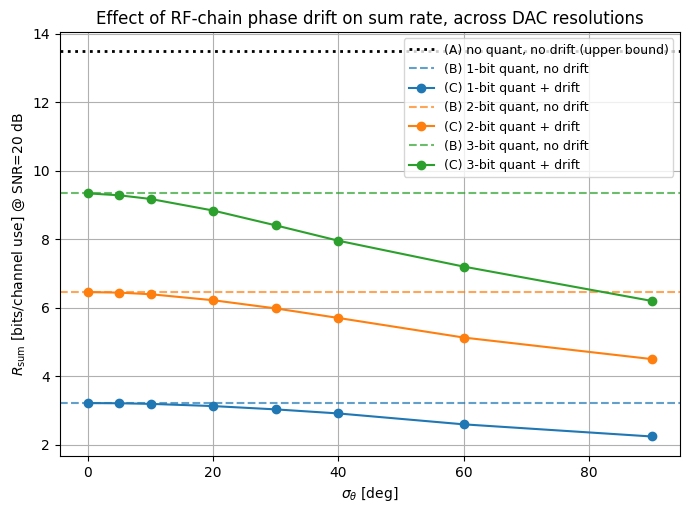

In [32]:
plt.figure(figsize=(8, 5.5))
plt.axhline(Rsum_A_ref, color='black', linestyle=':', linewidth=2, label='(A) no quant, no drift (upper bound)')

for b in bits_list:
    c = bit_colors[b]
    plt.axhline(Rsum_B_by_bits[b], color=c, linestyle='--', alpha=0.7, label=f'(B) {b}-bit quant, no drift')
    plt.plot(sigma_theta_deg_sweep, Rsum_C_sweep_by_bits[b], color=c, marker='o', label=f'(C) {b}-bit quant + drift')

plt.xlabel(r'$\sigma_\theta$ [deg]')
plt.ylabel(r'$R_{\mathrm{sum}}$ [bits/channel use]' + f' @ SNR={snr_points[snr_idx]} dB')
plt.title('Effect of RF-chain phase drift on sum rate, across DAC resolutions')
plt.legend(fontsize=9)
plt.grid(True)
plt.show()

## Decomposing the trade-off: coherent gain loss vs. distortion decorrelation, across DAC resolutions

Two competing effects of phase drift, isolated using the diagnostics returned by `simulate_rsum_phase_drift`, one line per bit depth (same color coding as the plot above):
- **Coherent signal power** (`coherent_pwr`, from $|\mathrm{diag}(H^T G)|^2$, shown relative to its own $\sigma_\theta=0$ value): drops as $\sigma_\theta$ grows — this is the harmful effect, the same beamforming-gain loss reported in the reference WPT paper. Should be roughly bit-depth-independent, since it reflects the precoder/channel geometry rather than the quantizer.
- **Distortion spatial-correlation ratio** (`dist_offdiag_ratio`, off-diagonal vs. diagonal energy of $C_q$): should drop as $\sigma_\theta$ grows — this is the potentially beneficial, dithering-like effect, and only exists because of quantization, so it should show up **more strongly at lower bit depths** (coarser quantizer -> more structured/correlated distortion to begin with -> more to gain from decorrelating it).

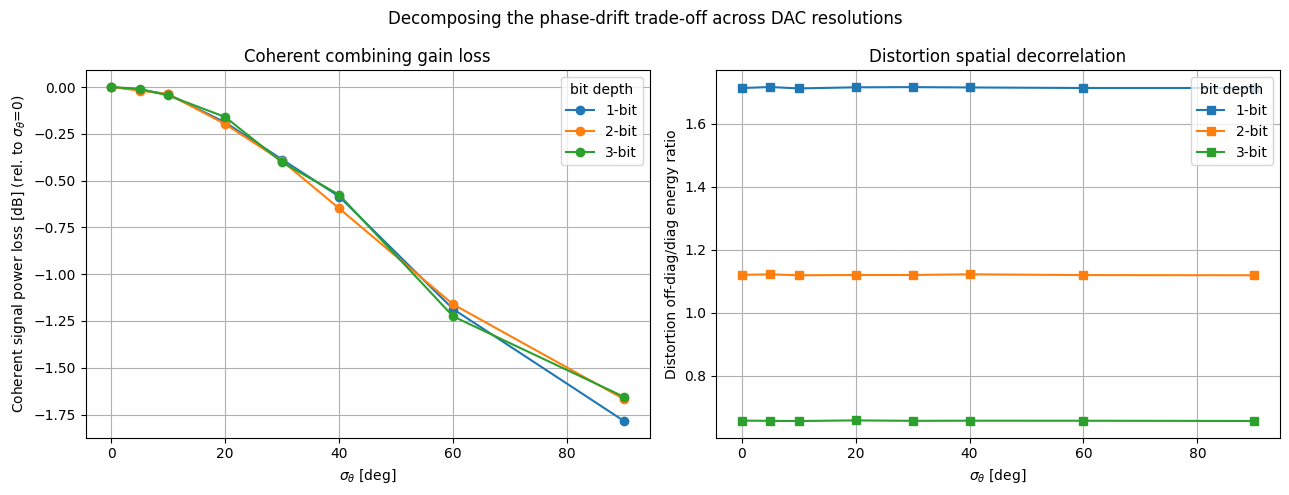

--- 1-bit ---
Rsum @ SNR=20dB vs sigma_theta  (A=13.479, B=3.212):
  sigma_theta=  0 deg -> Rsum=3.211
  sigma_theta=  5 deg -> Rsum=3.207
  sigma_theta= 10 deg -> Rsum=3.188
  sigma_theta= 20 deg -> Rsum=3.124
  sigma_theta= 30 deg -> Rsum=3.027
  sigma_theta= 40 deg -> Rsum=2.908
  sigma_theta= 60 deg -> Rsum=2.591
  sigma_theta= 90 deg -> Rsum=2.236
--- 2-bit ---
Rsum @ SNR=20dB vs sigma_theta  (A=13.479, B=6.452):
  sigma_theta=  0 deg -> Rsum=6.452
  sigma_theta=  5 deg -> Rsum=6.437
  sigma_theta= 10 deg -> Rsum=6.390
  sigma_theta= 20 deg -> Rsum=6.215
  sigma_theta= 30 deg -> Rsum=5.976
  sigma_theta= 40 deg -> Rsum=5.697
  sigma_theta= 60 deg -> Rsum=5.125
  sigma_theta= 90 deg -> Rsum=4.497
--- 3-bit ---
Rsum @ SNR=20dB vs sigma_theta  (A=13.479, B=9.338):
  sigma_theta=  0 deg -> Rsum=9.335
  sigma_theta=  5 deg -> Rsum=9.279
  sigma_theta= 10 deg -> Rsum=9.172
  sigma_theta= 20 deg -> Rsum=8.834
  sigma_theta= 30 deg -> Rsum=8.401
  sigma_theta= 40 deg -> Rsum=7.952
  sigma

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for b in bits_list:
    c = bit_colors[b]
    coherent_pwr_loss_db = 10 * np.log10(coherent_pwr_sweep_by_bits[b] / coherent_pwr_sweep_by_bits[b][0])
    ax1.plot(sigma_theta_deg_sweep, coherent_pwr_loss_db, marker='o', color=c, label=f'{b}-bit')
    ax2.plot(sigma_theta_deg_sweep, dist_ratio_sweep_by_bits[b], marker='s', color=c, label=f'{b}-bit')

ax1.set_xlabel(r'$\sigma_\theta$ [deg]')
ax1.set_ylabel(r'Coherent signal power loss [dB] (rel. to $\sigma_\theta$=0)')
ax1.set_title('Coherent combining gain loss')
ax1.grid(True)
ax1.legend(title='bit depth')

ax2.set_xlabel(r'$\sigma_\theta$ [deg]')
ax2.set_ylabel('Distortion off-diag/diag energy ratio')
ax2.set_title('Distortion spatial decorrelation')
ax2.grid(True)
ax2.legend(title='bit depth')

fig.suptitle('Decomposing the phase-drift trade-off across DAC resolutions')
fig.tight_layout()
plt.show()

for b in bits_list:
    print(f'--- {b}-bit ---')
    print(f'Rsum @ SNR={snr_points[snr_idx]}dB vs sigma_theta  (A={Rsum_A_ref:.3f}, B={Rsum_B_by_bits[b]:.3f}):')
    for deg, r in zip(sigma_theta_deg_sweep, Rsum_C_sweep_by_bits[b]):
        print(f'  sigma_theta={deg:>3} deg -> Rsum={r:.3f}')